In [29]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import shap

In [2]:
# CONSTANTS
DIR = "data/"
DATASET = DIR + "analysisofcountriesFCC.csv"

SEED = 42
TRAIN_SIZE = 0.7
TEST_SIZE = 1 - TRAIN_SIZE
OBJECTIVE = "number of sessions"

# 1.1. Carga y preparación del dataset

In [3]:
# Carga del dataset
df = pd.read_csv(DATASET, sep=";", na_values=["#N/A"])
df.head()

,country,number of sessions,internet population (descendent order),ses/intpop,ses/(48%*tot_population),connectivity_index,ordered by number of citygroups (1==0),ISO3136,engprof
0,Afghanistan,10,30,16,6,6,2,AF,35.0
1,Albania,28,29,48,63,77,2,AL,35.0
2,Algeria,51,67,28,17,12,4,DZ,40.0
3,Argentina,86,98,47,60,72,5,AR,60.0
4,Armenia,31,20,64,64,51,2,AM,35.0


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 119 non-null    object 
 1   number of sessions                      119 non-null    int64  
 2   internet population (descendent order)  119 non-null    int64  
 3   ses/intpop                              119 non-null    int64  
 4   ses/(48%*tot_population)                119 non-null    int64  
 5   connectivity_index                      119 non-null    int64  
 6   ordered by number of citygroups (1==0)  119 non-null    int64  
 7   ISO3136                                 119 non-null    object 
 8   engprof                                 115 non-null    float64
dtypes: float64(1), int64(6), object(2)
memory usage: 8.5+ KB


None

Al observar el dataset, se observan las distintas variables:
- **country**: Variable categórica que contiene el nombre del país.
- **number of sessions**: Sesiones registradas en freeCodeCamp en el país.
- **internet population**: Población de dicho país con conexión a internet.
- **ses/intpop**: Relación entre internet population y number of sessions.
- **ses/(48%*tot_population)**: Relación entre internet population y number of sessions ajustada por un porcentaje.
- **connectivity_index**: Índice de conectividad del país.
- **ordered by number of citygroups (1==0)**: Indica la presencia de comunidades locales en el país.
- ISO3136: Variable categórica que contiene el código del país.
- **engprof**: Nivel del dominio del inglés en el país.

In [5]:
# Eliminación de nulos
display(df.isna().sum())
print("Número de filas antes de eliminar nulos:", len(df))
df = df.dropna()
print("Número de filas después de eliminar nulos:", len(df))

country                                   0
number of sessions                        0
internet population (descendent order)    0
ses/intpop                                0
ses/(48%*tot_population)                  0
connectivity_index                        0
ordered by number of citygroups (1==0)    0
ISO3136                                   0
engprof                                   4
dtype: int64

Número de filas antes de eliminar nulos: 119
Número de filas después de eliminar nulos: 115


Se observa que hay 4 registros con valores nulos en la variable **engprof**. Se van a eliminar dichos registros.

In [6]:
variables_numericas = df.select_dtypes(include="number")
rangos_intervalo = variables_numericas.agg(["min", "max"]).T
rangos_intervalo

,min,max
number of sessions,1.0,119.0
internet population (descendent order),2.0,119.0
ses/intpop,1.0,119.0
ses/(48%*tot_population),1.0,119.0
connectivity_index,1.0,119.0
ordered by number of citygroups (1==0),1.0,19.0
engprof,25.0,100.0


Al examinar los datos, se observa cómo no hay valores negativos en las variables numéricas, por lo que no se debe realizar tratamiento de valores negativos. 

Se va a observar si existen registros duplicados de la columna **country**.

In [7]:
df["country"][df["country"].duplicated(keep=False)].sort_values()

Series([], Name: country, dtype: object)

Como se observa, dicha variable no tiene ningún registro duplicado. En otras palabras, cada registro posee su propio valor. Por dicha razón, la variable no es útil para las predicciones al no haber posibles patrones entre distintos registros. Por esto se va a eliminar la columna del dataset. Se va a realizar lo mismo con la columna "**ISO3136**", dado que esta representa el código de cada país. En otras palabras, representa la misma información.

In [8]:
df = df.drop(columns=["country","ISO3136"])

Por último, también se va a eliminar **ses/intpop** y **ses/(48%*tot_population),** ya que sus valores dependen directamente de **number of sessions**, por lo que puede provocar data leakage.

In [9]:
df = df.drop(columns=["ses/intpop","ses/(48%*tot_population)"])

In [10]:
df.duplicated().sum()

np.int64(0)

También se observa que no existen valores duplicados, por lo que no es requerido su tratamiento.

Al final se han realizado los siguientes pasos sobre el dataset:
- Eliminación de nulos.
- Eliminación de las variables **country**, **ISO3136**, **ses/intpop** y **ses/(48%*tot_population)**.

El dataset acaba quedando de la siguiente manera:

In [11]:
df.head()

,number of sessions,internet population (descendent order),connectivity_index,ordered by number of citygroups (1==0),engprof
0,10,30,6,2,35.0
1,28,29,77,2,35.0
2,51,67,12,4,40.0
3,86,98,72,5,60.0
4,31,20,51,2,35.0


Por último, se van a realizar los pasos finales:
- Separar la variable objetivo del resto de variables.
- Dividir los datos en entrenamiento y validación.

En este caso no se va a estandarizar el dataset antes de entrenar el modelo, ya que Random Forest trabaja mediante árboles y reglas de decisión sobre los valores de las variables.


La variable objetivo que se ha seleccionado es **number of sessions**. Esta variable representa el número de sesiones de freeCodeCamp asociadas a cada país, por lo que constituye el resultado principal que se quiere predecir. Y, dado que **number of sessions** es una variable numérica, el problema puede plantearse como una tarea de regresión. El objetivo del modelo es estimar cuántas sesiones puede generar un país a partir de variables presentes en el dataset.

In [12]:
X = df.drop(columns=[OBJECTIVE])
y = df[OBJECTIVE]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de validación: {X_test.shape[0]} filas")
print(f"Variables explicativas: {list(X_train.columns)}")

Tamaño de entrenamiento: 80 filas
Tamaño de validación: 35 filas
Variables explicativas: ['internet population (descendent order)', 'connectivity_index', 'ordered by number of citygroups (1==0)', 'engprof']


# 1.2. Entrenamiento del modelo

En este notebook se va a entrenar un modelo **Random Forest Regressor**. Random Forest combina varios árboles entrenados con muestras diferentes del dataset, siendo la predicción final un promedio las predicciones de los distintos árboles.

In [13]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    min_samples_leaf=2,
    n_jobs=-1
)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

# 1.3. Explicación del modelo

Ya que **Random Forest** es menos interpretable que la regresión lineal, ya que no se puede explicar simplemente observando un coeficiente por variable, se van a usar métodos de explicación como importancia de atributos, LIME y SHAP.

En concreto, se van a realizar tres tipos de análisis:

- **Evaluación del error**, para observar cómo se comporta el modelo en validación.
- **Explicación global**, observando qué variables tienen más importancia para el modelo.
- **Explicación individual**, usando una aproximación local basada en LIME y una explicación opcional con SHAP.

## 1.3.1. Evaluación del error del modelo

Antes de explicar el modelo, se van a observar sus predicciones y sus errores. En este caso, como la variable objetivo es numérica, se calculan métricas de regresión y se representa la relación entre valores reales y valores predichos. Esta parte permitirá comprobar si el modelo tiene un comportamiento razonable antes de realizar la explicación global e individual.

In [14]:
rf_results = pd.DataFrame({
    "real_value": y_test,
    "predicted_value": y_pred_rf,
    "error": y_test - y_pred_rf,
    "absolute_error": (y_test - y_pred_rf).abs()
})
rf_results.head(10)

,real_value,predicted_value,error,absolute_error
85,109,105.685623,3.314377,3.314377
4,31,27.105681,3.894319,3.894319
42,14,14.168429,-0.168429,0.168429
73,57,66.054280,-9.054280,9.054280
11,73,52.403694,20.596306,20.596306
47,90,98.036946,-8.036946,8.036946
74,104,78.990408,25.009592,25.009592
70,41,24.172087,16.827913,16.827913
49,20,25.570579,-5.570579,5.570579
12,80,74.792727,5.207273,5.207273


In [15]:
rf_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_test, y_pred_rf),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        r2_score(y_test, y_pred_rf)
    ]
})
rf_metrics

,metric,value
0,MAE,11.493239
1,RMSE,14.705768
2,R2,0.829804


Se observa que el modelo obtiene un **MAE de 11.49**, un **RMSE de 14.71** y un **R2 de 0.830**. Por tanto, **Random Forest** obtiene mejores resultados que la regresión lineal en este conjunto de validación.

Aun así, el objetivo principal del ejercicio no es conseguir el mejor rendimiento ni realizar una comparación de modelos, sino explicar el comportamiento del modelo ante el dataset. Por esto, después de observar las métricas, se van a analizar las variables que más influyen en el modelo y una instancia concreta.

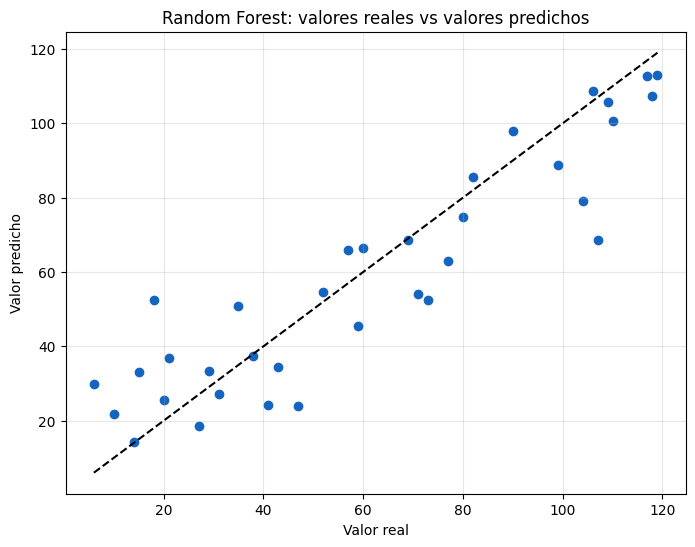

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color="#1565C0")
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Random Forest: valores reales vs valores predichos")
plt.grid(alpha=0.3)
plt.show()

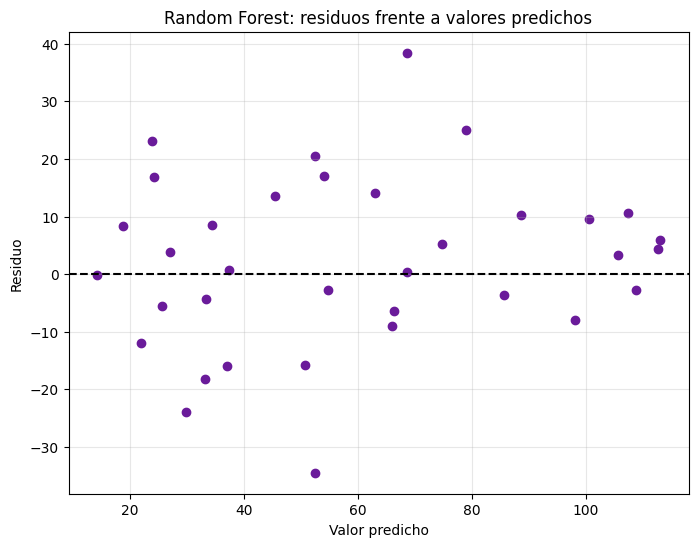

In [ ]:
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, rf_residuals, color="#6A1B9A")
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Random Forest: residuos frente a valores predichos")
plt.grid(alpha=0.3)
plt.show()

En la gráfica de valores reales frente a valores predichos se observa que el Random Forest se aproxima mejor a la diagonal que la regresión lineal. De las 35 instancias del conjunto de validación, 19 tienen un error absoluto menor o igual que 10 sesiones y 29 tienen un error absoluto menor o igual que 20 sesiones. Esto indica un rendimiento global relativamente estable.

Sin embargo, la gráfica también muestra algunos puntos alejados. El caso más claro es una instancia cuyo valor real es 107 sesiones y cuya predicción es de 68.55. También se observa una cuyo valor real es 18 sesiones y cuya predicción es 52.48. Por tanto, el modelo obtiene un rendimiento general bastante aceptable, pero aun así falla en algunas instancias concretas.

En la gráfica de residuos se observa que los errores están bastante repartidos entre ambos sentidos: hay 20 infraestimaciones y 15 sobreestimaciones. La media del error es aproximadamente 2.20, por lo que no se observa un sesgo medio muy fuerte. Aun así, los errores extremos siguen siendo relevantes.

## 1.3.2. Explicación global mediante importancia de atributos

Como Random Forest está formado por varios árboles, no se interpreta mediante un único coeficiente como ocurre con la regresión lineal. 

En este caso se va a observar la importancia de atributos del propio modelo. Esta explicación es global porque resume el comportamiento del modelo completo, indicando las variables que tuvieron más importancia en todos los árboles en lugar de en una única instancia.

In [ ]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest_model.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_feature_importance

,feature,importance
2,ordered by number of citygroups (1==0),0.483568
0,internet population (descendent order),0.337482
3,engprof,0.093070
1,connectivity_index,0.085880


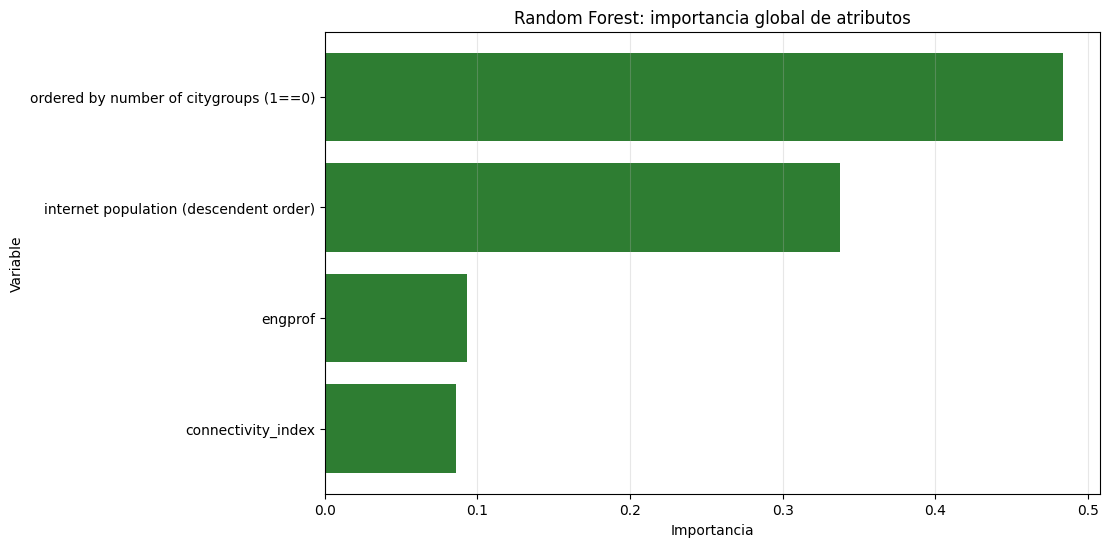

In [ ]:
importance_sorted = rf_feature_importance.sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_sorted["feature"], importance_sorted["importance"], color="#2E7D32")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Random Forest: importancia global de atributos")
plt.grid(axis="x", alpha=0.3)
plt.show()

Tanto en la gráfica como en la tabla se puede observar cómo **ordered by number of citygroups (1==0)** es la variable más importante, teniendo una importancia aproximada de **0.484**. Tras esta está **internet population (descendent order)** con una importancia de **0.337**, **engprof** con **0.093** y **connectivity_index** con un valor de **0.086**.

Por dicha razón, se puede deducir que las predicciones de **Random Forest** están principalmente influenciadas por **ordered by number of citygroups (1==0)** e **internet population (descendent order)** para realizar en mejor medida la separación de los casos.

Por esto es realmente importante que dichas variables tengan valores suficientemente representativos en dichas variables, pues en caso contrario el porcentaje de errores en las predicciones aumentaría.

## 1.3.3. Instancias con mayor error

Antes de realizar una explicación individual, se van a observar las instancias con mayor error absoluto. Se selecciona la instancia más problemática, ya que esta permitirá analizar con más detalle por qué el modelo se aleja del valor real.

In [ ]:
rf_top_errors = rf_results.sort_values(by="absolute_error", ascending=False).head(10)
rf_top_errors

,real_value,predicted_value,error,absolute_error
104,107,68.551766,38.448234,38.448234
109,18,52.477060,-34.477060,34.477060
74,104,78.990408,25.009592,25.009592
10,6,29.847468,-23.847468,23.847468
17,47,23.924806,23.075194,23.075194
11,73,52.403694,20.596306,20.596306
76,15,33.213911,-18.213911,18.213911
24,71,54.016877,16.983123,16.983123
70,41,24.172087,16.827913,16.827913
82,21,36.947754,-15.947754,15.947754


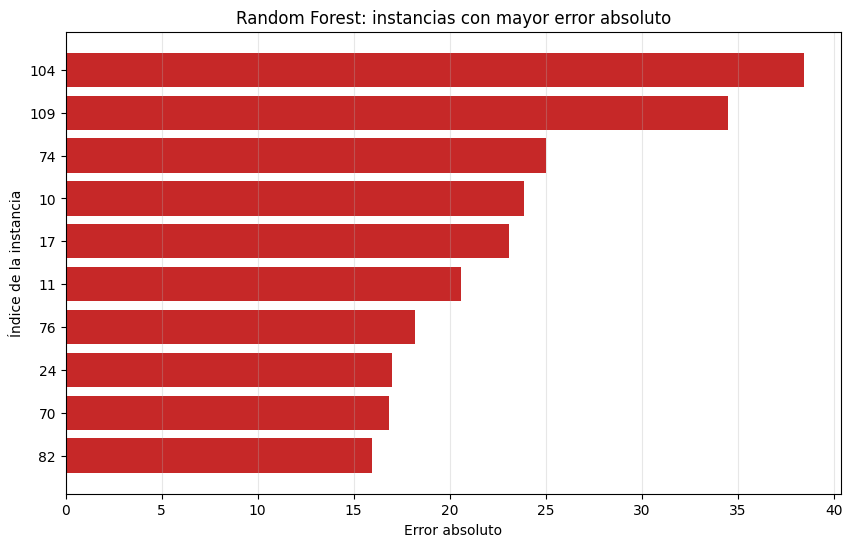

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(rf_top_errors.index.astype(str), rf_top_errors["absolute_error"], color="#C62828")
plt.ylabel("Índice de la instancia")
plt.xlabel("Error absoluto")
plt.title("Random Forest: instancias con mayor error absoluto")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

Al examinar el error absoluto en las predicciones, se puede apreciar cómo las peores predicciones son la 104 con 38.45 sesiones de error absoluto, la 109 con 34.48 y la 74 con 25.01.

Aunque es importante mencionar que, incluso aunque hay 2 instancias con un error absoluto muy alto, en líneas generales la mayoría de las predicciones poseen un error absoluto muy por debajo. Esto indica que, aunque el modelo aún predice determinadas instancias de manera bastante alejada de su valor real, en líneas generales el modelo realiza predicciones medianamente acertadas.

## 1.3.4. Explicación individual: predicción de los árboles

En **Random Forest**, la predicción final se obtiene como la media de las predicciones de todos los árboles, por lo que para observar cómo se ha realizado la predicción de una instancia concreta es esencial observar cómo ha realizado dicha predicción cada árbol.

In [ ]:
selected_index = rf_results.sort_values(by="absolute_error", ascending=False).index[0]
selected_instance = X_test.loc[[selected_index]]
selected_result = rf_results.loc[[selected_index]]

print(f"Instancia seleccionada: {selected_index}")
display(selected_instance)
display(selected_result)

Instancia seleccionada: 104


,internet population (descendent order),connectivity_index,ordered by number of citygroups (1==0),engprof
104,91,99,2,53.0


,real_value,predicted_value,error,absolute_error
104,107,68.551766,38.448234,38.448234


,count,mean,std,min,25%,50%,75%,max
tree_prediction,300.0,68.551766,15.594512,19.0,59.458333,67.125,80.0,105.5


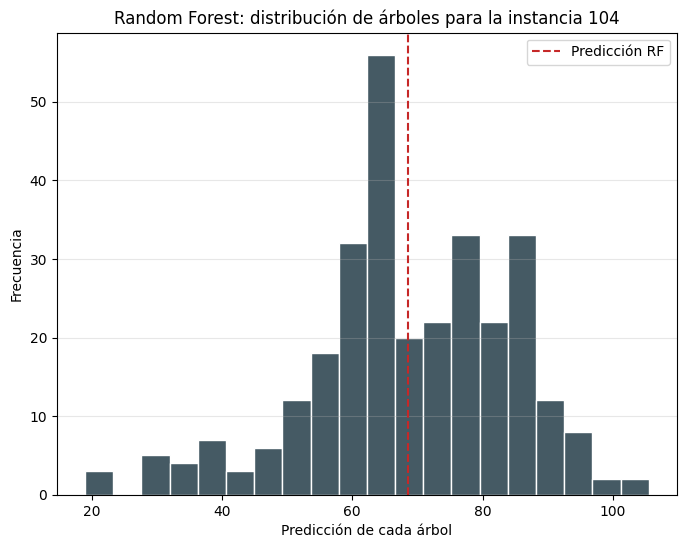

In [ ]:
tree_predictions = pd.Series(
    [tree.predict(selected_instance.values)[0] for tree in random_forest_model.estimators_],
    name="tree_prediction"
)

display(tree_predictions.describe().to_frame().T)

selected_position = X_test.index.get_loc(selected_index)
plt.figure(figsize=(8, 6))
plt.hist(tree_predictions, bins=20, color="#455A64", edgecolor="white")
plt.axvline(y_pred_rf[selected_position], linestyle="--", color="#C62828", label="Predicción RF")
plt.xlabel("Predicción de cada árbol")
plt.ylabel("Frecuencia")
plt.title(f"Random Forest: distribución de árboles para la instancia {selected_index}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

Se ha seleccionado la instancia 104, cuyo valor real es de 107 sesiones, mientras que **Random Forest Regressor** predice aproximadamente **68.55** sesiones. Esto indica que el modelo infraestima de forma notable esta instancia, por lo que se va a analizar el motivo de dicha infraestimación.

En el histograma se observa que prácticamente todo el bosque predice valores inferiores al valor real. De hecho, las predicciones individuales de los árboles tienen una media de **68.55**, una mediana aproximada de 67.12, un mínimo de 19 y un máximo de 105.5. Es decir, ningún árbol alcanza siquiera el valor real de 107 sesiones.

Por esta razón, se puede deducir que el error no se debe a la presencia de unos pocos árboles con predicciones especialmente erróneas, sino a una tendencia general del bosque a situar esta instancia por debajo de su valor real. Como la predicción final de Random Forest se obtiene promediando las predicciones de los árboles, esta tendencia colectiva provoca que el resultado final quede considerablemente alejado del valor observado.

Una posible explicación es que, para esta instancia, el modelo no encuentra en el conjunto de entrenamiento suficientes casos similares con valores tan altos de sesiones. Dado que los árboles de decisión realizan predicciones basadas en promedios de las observaciones presentes en sus hojas, el modelo tiende a devolver valores dentro del rango aprendido y tiene dificultades para extrapolar hacia valores superiores.

Para mejorar este comportamiento, una opción sería ampliar el conjunto de datos incorporando más instancias representativas, especialmente casos similares con valores altos de sesiones. Esto podría ayudar al modelo a aprender mejor este tipo de patrones y reducir la infraestimación. No obstante, la incorporación de nuevos datos debe hacerse con cuidado, verificando que sean representativos y que no introduzcan sesgos o ruido que perjudiquen la capacidad de generalización del modelo.

## 1.3.5. Explicación individual con LIME

A continuación, se va a realizar una explicación local basada en **LIME**.

*LIME* intenta explicar una predicción concreta usando un modelo más simple alrededor de la instancia que se quiere explicar. Para ello se generan ejemplos parecidos a la instancia seleccionada, se obtiene la predicción del **Random Forest** para esos ejemplos y se entrena un modelo sustituto local. 

Por dicha razón, esta explicación no debe entenderse como una descomposición exacta del **Random Forest**, sino como una aproximación local que permite interpretar mejor una predicción concreta.

In [ ]:
rng = np.random.default_rng(SEED)
n_lime_samples = 3000
feature_std = X_train.std(ddof=0).replace(0, 1)

lime_neighborhood = rng.normal(
    loc=selected_instance.iloc[0].values,
    scale=feature_std.values * 0.75,
    size=(n_lime_samples, X_train.shape[1])
)
lime_neighborhood = pd.DataFrame(lime_neighborhood, columns=X_train.columns)

for feature in X_train.columns:
    lower_value = X_train[feature].min()
    upper_value = X_train[feature].max()
    lime_neighborhood[feature] = lime_neighborhood[feature].clip(lower_value, upper_value)

lime_blackbox_predictions = random_forest_model.predict(lime_neighborhood)

lime_scaler = StandardScaler().fit(X_train)
lime_neighborhood_scaled = lime_scaler.transform(lime_neighborhood)
selected_instance_scaled = lime_scaler.transform(selected_instance)[0]

distances = np.sqrt(((lime_neighborhood_scaled - selected_instance_scaled) ** 2).sum(axis=1))
kernel_width = 0.3 * np.sqrt(X_train.shape[1])
lime_weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

lime_surrogate = Ridge(alpha=1.0)
lime_surrogate.fit(lime_neighborhood_scaled, lime_blackbox_predictions, sample_weight=lime_weights)

lime_surrogate_predictions = lime_surrogate.predict(lime_neighborhood_scaled)
weighted_average_prediction = np.average(lime_blackbox_predictions, weights=lime_weights)
weighted_residual_sum = np.sum(lime_weights * (lime_blackbox_predictions - lime_surrogate_predictions) ** 2)
weighted_total_sum = np.sum(lime_weights * (lime_blackbox_predictions - weighted_average_prediction) ** 2)
lime_local_r2 = 1 - weighted_residual_sum / weighted_total_sum

lime_local_explanation = pd.DataFrame({
    "feature": X_train.columns,
    "original_value": selected_instance.iloc[0].values,
    "scaled_value": selected_instance_scaled,
    "lime_coefficient": lime_surrogate.coef_,
    "local_contribution": selected_instance_scaled * lime_surrogate.coef_
})
lime_local_explanation["absolute_local_contribution"] = lime_local_explanation["local_contribution"].abs()
lime_local_explanation = lime_local_explanation.sort_values(
    by="absolute_local_contribution",
    ascending=False
)

print(f"Predicción Random Forest: {random_forest_model.predict(selected_instance)[0]:.2f}")
print(f"Predicción del sustituto local LIME: {lime_surrogate.predict(selected_instance_scaled.reshape(1, -1))[0]:.2f}")
print(f"R2 local ponderado del sustituto: {lime_local_r2:.3f}")
lime_local_explanation

Predicción Random Forest: 68.55
Predicción del sustituto local LIME: 64.40
R2 local ponderado del sustituto: 0.859


,feature,original_value,scaled_value,lime_coefficient,local_contribution,absolute_local_contribution
2,ordered by number of citygroups (1==0),2.0,-0.635251,23.708929,-15.061126,15.061126
0,internet population (descendent order),91.0,0.864966,7.718208,6.675986,6.675986
3,engprof,53.0,-0.128038,17.515586,-2.242661,2.242661
1,connectivity_index,99.0,1.148259,-0.048603,-0.055809,0.055809


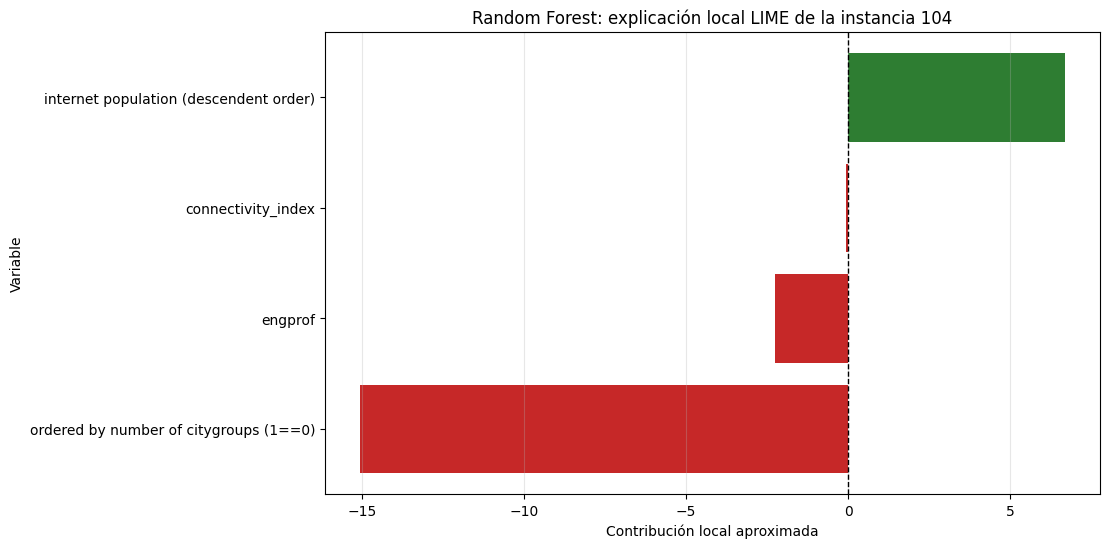

In [ ]:
lime_sorted = lime_local_explanation.sort_values(by="local_contribution", ascending=True)
colors = np.where(lime_sorted["local_contribution"] >= 0, "#2E7D32", "#C62828")

plt.figure(figsize=(10, 6))
plt.barh(lime_sorted["feature"], lime_sorted["local_contribution"], color=colors)
plt.xlabel("Contribución local aproximada")
plt.ylabel("Variable")
plt.title(f"Random Forest: explicación local LIME de la instancia {selected_index}")
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.show()

Se observa que el sustituto local de **LIME** obtiene un **R2** local ponderado de 0.859, por lo que aproxima razonablemente el comportamiento del **Random Forest** alrededor de la instancia seleccionada. Aun así, su predicción aproximada es 64.40, mientras que la predicción del **Random Forest** es 68.55, por lo que no coincide exactamente.

En la gráfica de contribuciones locales se observa que la variable que más empuja la predicción hacia abajo es **ordered by number of citygroups (1==0)**, con una contribución aproximada de -15.06. También reduce la predicción **engprof**, con una contribución aproximada de -2.24. En cambio, **internet population (descendent order)** aumenta la predicción en aproximadamente 6.68.

Por tanto, la gráfica permite deducir que el bajo valor predicho para esta instancia se explica principalmente por la contribución negativa de **ordered by number of citygroups (1==0)**. Esto es coherente con el error observado anteriormente: el modelo predice demasiado bajo y la explicación local muestra que la variable más importante globalmente también empuja esta predicción concreta hacia abajo.

# 1.4. Uso de IA generativa

El primer prompt utilizado fue para entender en mejor medida el ejercicio y los requisitos para cumplir. Se le envió a ChatGPT el enunciado entero del ejercicio.

```
PROJECT TASK 
The goal of practical project is to explain, using all suitable techniques explained in class, the ML models assigned. At least each team must explain 2 ML models (a.k.a. compulsory models). Additionally, the team can build and explain a third model (a.k.a. extra model). 

The Practical Project will consist of: 
• Python 2 or 3 notebooks: ipynb file for each model. 
• Dataset: csv file or online load hardcoded. 

Each notebook must include: 
• Markdown use: o Sections and subsections numbered (using #, ##, etc.) o Concise and clear descriptions of the decisions made o Concise and clear conclusions of the explanations obtained. 
• The code must be clear and must include comments. 
• The notebook must include 3 sections (you can add subsections): 
1. Dataset load and preparation 
2. ML model training 
3. ML explanation 
4. Generative AI section (see genAI disclaimant) 

The ML explanation, section 3, is the most important part of the project. Here you should cover: 
• Use any explanation method useful that you’ve seen on class. 
• Provide individual explanations of instance. Not just plots, but the conclusions you can make. 
• Provide global explanations of the ML model. Not just plots, but the conclusions you can make. 

IMPORTANT You must perform data preparation pipeline and model training properly. However, do not focus on doing a great data preparation pipeline. Do not focus on training the best ML model ever! This subject is about explaining a model, not building it. You will not get a better mark if you make a great work on sections 1,2. 

Que me pide exactamente el ejercicio?
```

El siguiente prompt fue para determinar, de las dos opciones a elegir, cuál es la más sencilla de implementar.

```
Versión 1: 
- Datasets: https://data.nysed.gov/downloads.php (debo elegir un dataset pequeño) 
- Debe ser una tarea de clasificación 
- Modelos a utilizar: LogisticReg, Random Forest, Basic Neuronal Network (solo debo elegir dos) 

Versión 2: 
- Dataset: https://github.com/freeCodeCamp/open-data/tree/master/google-analytics/countries-fCC/data 
- Debe ser una tarea de regresión 
- Modelos a utilizar: Linear Reg, Random Forest Reg, SVN regression (solo debo elegir dos) 

Cual de las dos versiones consideras que es más sencilla de utilizar?
```

Fue así como me recomendó utilizar la versión 2 con Linear Reg y Random Forest.

También quise un análisis más detallado del contexto del dataset elegido, así que directamente se lo pregunté.

```
Explícame en qué consiste el dataset
```

Tras realizar la preparación inicial del dataset, pregunté si sería recomendable que aplicara algo más.

```
Al dataset le aplico esto: 
- cargo el dataset 
- elimino los nulos 
- Miro si hay valores negativos, los cuales no hay 

Hago algo más?
```

A la hora de probar si había registros duplicados en la columna **columns**, intenté hacer el código por mi cuenta, pero no me funcionó, así que decidí consultar a ChatGPT.

```
Quiero ver los datos de Country que tengan más de 1 registro df[df["country"].value_counts() > 1].sort_values("country")
```

No me entendió de primeras, así que tuve que preguntarle de vuelta con otras palabras.

```
Lo que quiero es esto: 
Quedarme solo con la columna country y ver de entre dicha columna los valores duplicados que hay
```

Finalmente, hice este último prompt:

```
Para cada modelo, dame cuáles son las mejores métricas para evaluar a dicho modelo. 
Dame también algunos snippets de código.
```

Para que supiera mejor cómo se cursa la asignatura, le di contexto dándole información presente en las diapositivas de la asignatura. Y con las métricas que me recomendó, hice un cribado para elegir las que yo mejor consideraba. También usé dichos snippets de código, modificándolos para adecuarse en mejor medida a la práctica.